# 03 - Entrenamiento de modelos

Este cuaderno entrena y evalúa modelos de aprendizaje automático para la clasificación binaria de la orientación política.

El objetivo es comparar diferentes algoritmos de clasificación y seleccionar el modelo con mejor rendimiento para su posterior interpretación y aplicación.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [15]:
DATA_PATH = Path("../data/processed/political_orientation_clean.csv")
MODEL_PATH = Path("../app/best_model.pkl")
RESULTS_PATH = Path("../data/processed/model_results.csv")
FIGURES_PATH = Path("../figures")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

## 0. Cargar datos procesados

In [16]:
data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (16383, 74)


,P220,P2057,P605,P6210,P6945,P3039,P2001S1,P2001S2,P2001S3,P2001S4,...,P5314S2,P5314S3,P5314S4,P5314S5,P5314S6,P5314S7,P5317S1,P5317S9,P2009S9,political_orientation
0,1,2.0,3.0,6.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0
1,2,2.0,3.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,0
2,2,2.0,1.0,5.0,5.0,2.0,2.0,2.0,2.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0
3,2,1.0,2.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,0
4,1,1.0,2.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 74 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   P220                   16383 non-null  int64  
 1   P2057                  16383 non-null  float64
 2   P605                   16383 non-null  float64
 3   P6210                  16383 non-null  float64
 4   P6945                  16383 non-null  float64
 5   P3039                  16383 non-null  float64
 6   P2001S1                16383 non-null  float64
 7   P2001S2                16383 non-null  float64
 8   P2001S3                16383 non-null  float64
 9   P2001S4                16383 non-null  float64
 10  P2001S17               16383 non-null  float64
 11  P2001S7                16383 non-null  float64
 12  P2001S12               16383 non-null  float64
 13  P2001S13               16383 non-null  float64
 14  P2001S14               16383 non-null  float64
 15  P2

In [18]:
data["political_orientation"].value_counts().sort_index()

political_orientation
0     6235
1    10148
Name: count, dtype: int64

In [19]:
data["political_orientation"].value_counts(normalize=True).sort_index() * 100

political_orientation
0    38.057743
1    61.942257
Name: proportion, dtype: float64

## 1. Separar variables predictoras y objetivo

In [20]:
X = data.drop(columns=["political_orientation"])
y = data["political_orientation"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16383, 73)
y shape: (16383,)


## 2. División train-test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("y_test distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

X_train: (13925, 73)
X_test: (2458, 73)
y_train distribution:
political_orientation
0    38.061041
1    61.938959
Name: proportion, dtype: float64
y_test distribution:
political_orientation
0    38.039056
1    61.960944
Name: proportion, dtype: float64


## 3. Función de evaluación

In [22]:
import shap

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name,
    params=None,
    skip_shap=False,
    shap_threshold=None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import shap

    # ======================================
    # GridSearch 
    # ======================================
    if params is not None:
        final_model = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring="roc_auc",
            n_jobs=-1
        )
        final_model.fit(X_train, y_train)
        trained_model = final_model.best_estimator_

        print("Mejores parámetros:")
        print(final_model.best_params_)
        print("Mejor CV score:")
        print(final_model.best_score_)

    else:
        model.fit(X_train, y_train)
        trained_model = model

    # ======================================
    # Predicciones 
    # ======================================
    y_pred = trained_model.predict(X_test)

    if hasattr(trained_model, "predict_proba"):
        y_proba = trained_model.predict_proba(X_test)[:, 1]
    elif hasattr(trained_model, "decision_function"):
        scores = trained_model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        y_proba = None

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, y_pred, target_names=["Left", "Right"]))

    # ======================================
    # Metrics (TEST)
    # ======================================
    metrics_1 = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    # ======================================
    # Metrics (TRAIN) 
    # ======================================
    y_pred_train = trained_model.predict(X_train)

    if hasattr(trained_model, "predict_proba"):
        y_proba_train = trained_model.predict_proba(X_train)[:, 1]
    elif hasattr(trained_model, "decision_function"):
        scores = trained_model.decision_function(X_train)
        y_proba_train = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        y_proba_train = None

    metrics_2 = {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1_score": f1_score(y_train, y_pred_train),
        "roc_auc": roc_auc_score(y_train, y_proba_train) if y_proba_train is not None else np.nan
    }

    # ======================================
    # Gap
    # ======================================
    gap = {
        "acc": metrics_2["accuracy"] - metrics_1["accuracy"],
        "f1": metrics_2["f1_score"] - metrics_1["f1_score"],
        "auc": metrics_2["roc_auc"] - metrics_1["roc_auc"]
    }

    print(
        f"Gap ACC: {gap['acc']*100:.2f}% | "
        f"F1: {gap['f1']*100:.2f}% | "
        f"AUC: {gap['auc']*100:.2f}%"
    )

    if gap["acc"] > 0.10 or gap["f1"] > 0.10 or gap["auc"] > 0.08:
        print("Posible overfitting")
    else:
        print("OK")

    # ======================================
    # Confusion Matrix
    # ======================================
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=["Left", "Right"])
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    # ======================================
    # ROC
    # ======================================
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC - {model_name}")
        plt.tight_layout()
        plt.show()

    # ======================================
    # SHAP
    # ======================================
    if skip_shap:
        return trained_model, metrics_1, metrics_2, gap

    # subset para velocidad
    X_shap = X_test.sample(min(500, len(X_test)), random_state=55)

    try:
        explainer = shap.TreeExplainer(trained_model)

        shap_vals = explainer(
            X_shap,
            check_additivity=False
        )
        shap_array = shap_vals.values

    except Exception as e:
        print("SHAP no soportado:", e)
        return trained_model, metrics_1, metrics_2, gap

    # binary classification fix
    if shap_array.ndim == 3:
        shap_array  = shap_array[:, :, 1]

    shap.summary_plot(shap_array, X_shap) 

    mean_shap = np.abs(shap_array).mean(axis=0)

    shap_importance = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": mean_shap
    }).sort_values("mean_abs_shap", ascending=False)

    print("\nSHAP importance:")
    print(shap_importance)

    if shap_threshold is not None:
        selected = shap_importance[shap_importance["mean_abs_shap"] >= shap_threshold]["feature"].tolist()
        removed = shap_importance[shap_importance["mean_abs_shap"] < shap_threshold]["feature"].tolist()

        print("\nSelected features:", selected)
        print("Removed features:", removed)

    # ======================================
    # Return final
    # ======================================
    return trained_model, metrics_1, metrics_2, gap

In [23]:
params_tree = {
    "criterion": ["gini", "entropy", "log_loss"],

    "max_depth": [15, 17, 20],

    "min_samples_split": [2, 5, 10, 20],

    "min_samples_leaf": [1, 2, 5, 10],

    "max_features": [None, "sqrt", "log2"],

    "splitter": ["best", "random"],

    "ccp_alpha": [0.0, 0.001, 0.01, 0.05]
}

params_rf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5]
}

params_xgb = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.7,0.8,1],
    "colsample_bytree":[0.7,0.8,1]
}

parameters = {
    "Decision Tree" : params_tree ,
    "Random Forest" : params_rf , 
    "XGBoost" : params_xgb, 
    "Logistic Regression" : None,
    "Gradient Boosting" : None, 
}

## 4. Definición de los modelos

In [24]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

## 5. Entrenamiento y evaluación

c:\Users\User\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
              precision    recall  f1-score   support

        Left       0.47      0.60      0.53       935
       Right       0.71      0.59      0.64      1523

    accuracy                           0.59      2458
   macro avg       0.59      0.59      0.58      2458
weighted avg       0.62      0.59      0.60      2458

Gap ACC: -0.53% | F1: -0.15% | AUC: -0.91%
OK


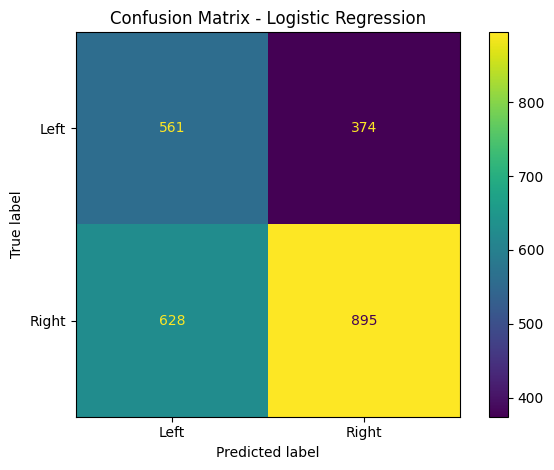

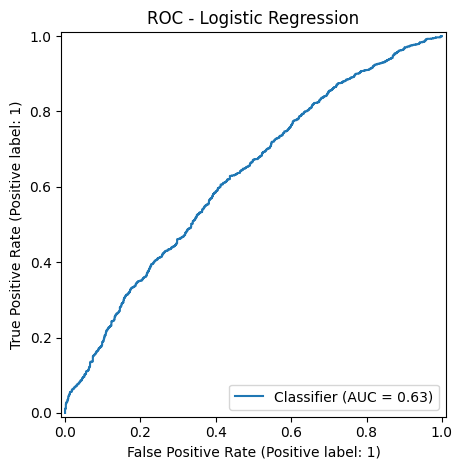

Mejores parámetros:
{'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'splitter': 'best'}
Mejor CV score:
0.722156412359858
Decision Tree
              precision    recall  f1-score   support

        Left       0.54      0.63      0.58       935
       Right       0.75      0.68      0.71      1523

    accuracy                           0.66      2458
   macro avg       0.65      0.65      0.65      2458
weighted avg       0.67      0.66      0.66      2458

Gap ACC: 2.21% | F1: 2.19% | AUC: 2.15%
OK


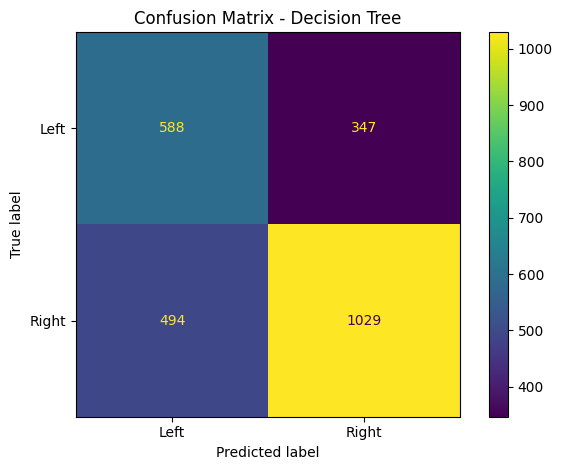

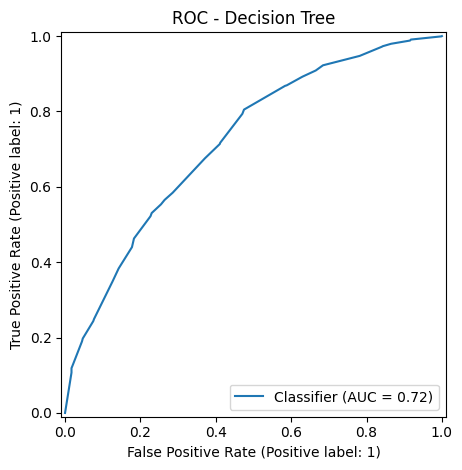

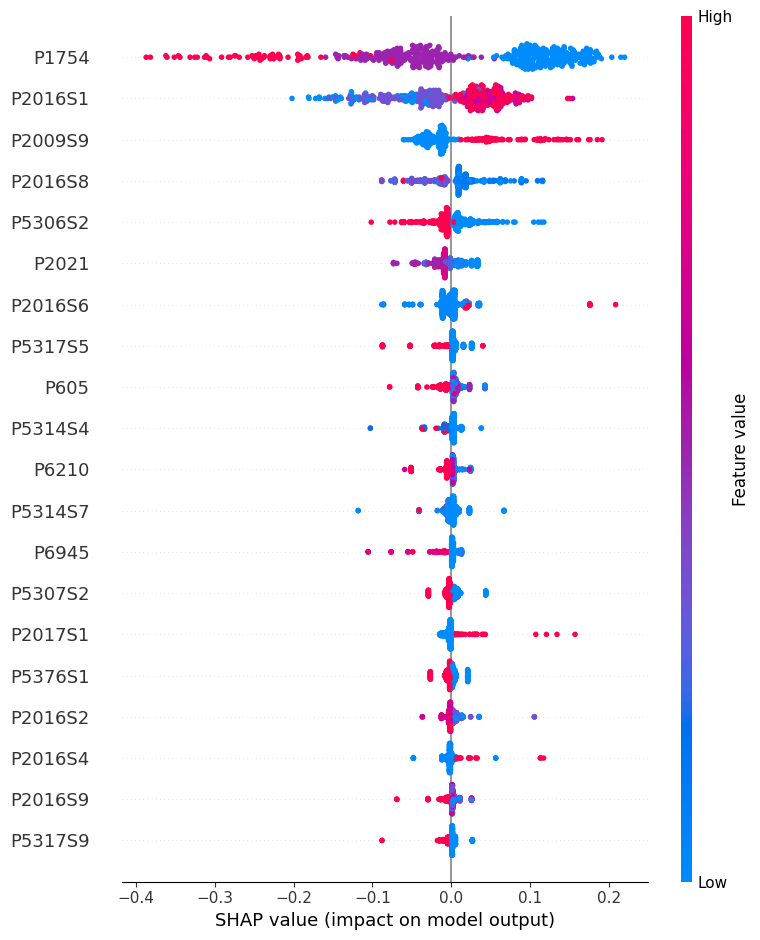


SHAP importance:
    feature  mean_abs_shap
49    P1754       0.110892
33  P2016S1       0.055308
72  P2009S9       0.033246
40  P2016S8       0.026611
31  P5306S2       0.016637
..      ...            ...
60  P5307S3       0.000000
63  P2017S7       0.000000
68  P5314S6       0.000000
65  P5314S3       0.000000
67  P5314S5       0.000000

[73 rows x 2 columns]

Selected features: ['P1754', 'P2016S1', 'P2009S9', 'P2016S8', 'P5306S2', 'P2021', 'P2016S6']
Removed features: ['P5317S5', 'P605', 'P5314S4', 'P6210', 'P5314S7', 'P6945', 'P5307S2', 'P2017S1', 'P5376S1', 'P2016S2', 'P2016S4', 'P2016S9', 'P5317S9', 'P5317S1', 'P5314S2', 'P5307S5', 'P5306S1', 'P5376S4', 'P2001S3', 'P2001S2', 'P2001S1', 'P3039', 'P2057', 'P220', 'P2003S14', 'P2001S4', 'P2003S4', 'P2001S17', 'P2001S7', 'P2001S12', 'P2001S13', 'P2001S14', 'P2001S15', 'P2001S18', 'P2016S7', 'P2016S5', 'P2016S3', 'P2003S18', 'P5373S5', 'P5373S4', 'P5373S6', 'P2019', 'P2003S15', 'P2001S10', 'P2003S17', 'P2003S7', 'P2003S10', 'P2003S12

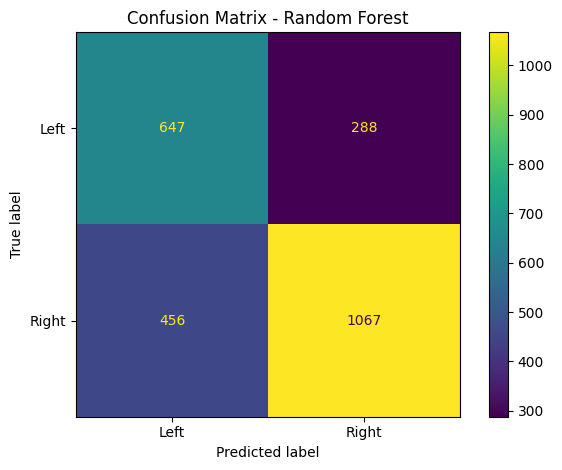

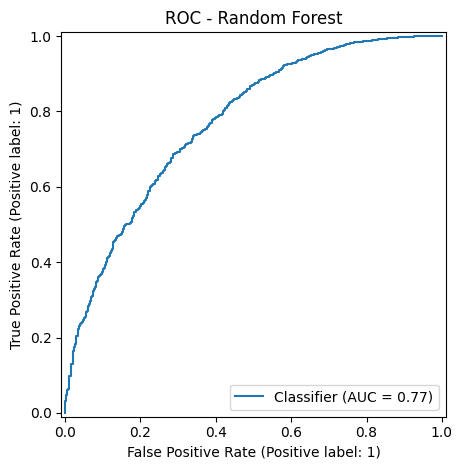

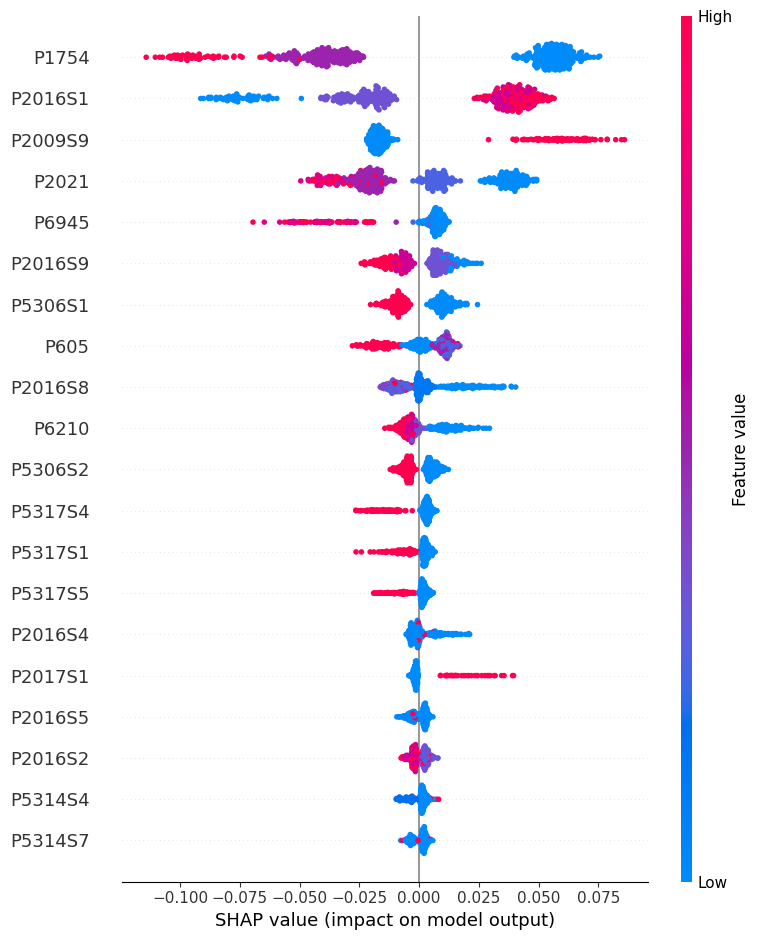


SHAP importance:
     feature  mean_abs_shap
49     P1754       0.054035
33   P2016S1       0.038549
72   P2009S9       0.026498
48     P2021       0.025076
4      P6945       0.012326
..       ...            ...
18  P2001S10       0.000018
26  P2003S18       0.000017
13  P2001S13       0.000010
10  P2001S17       0.000007
16  P2001S18       0.000006

[73 rows x 2 columns]

Selected features: ['P1754', 'P2016S1', 'P2009S9', 'P2021', 'P6945', 'P2016S9']
Removed features: ['P5306S1', 'P605', 'P2016S8', 'P6210', 'P5306S2', 'P5317S4', 'P5317S1', 'P5317S5', 'P2016S4', 'P2017S1', 'P2016S5', 'P2016S2', 'P5314S4', 'P5314S7', 'P2016S6', 'P2017S6', 'P2016S7', 'P5314S3', 'P5376S1', 'P5317S9', 'P2017S7', 'P2016S3', 'P5376S6', 'P5314S5', 'P5373S5', 'P5376S3', 'P2019', 'P5376S4', 'P5307S4', 'P5314S6', 'P5373S4', 'P3039', 'P2003S14', 'P5307S3', 'P2017S4', 'P2057', 'P2003S7', 'P5376S5', 'P2001S7', 'P2017S3', 'P2017S2', 'P2003S15', 'P220', 'P2017S5', 'P5307S5', 'P2001S4', 'P5314S2', 'P5307S2', 'P2001S

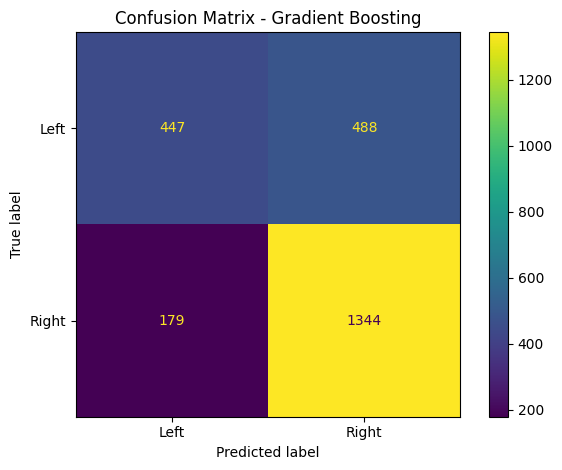

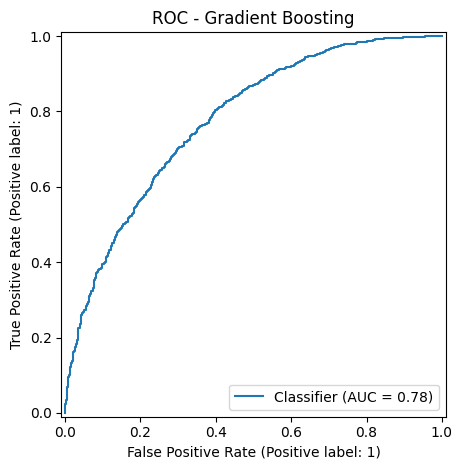

Mejores parámetros:
{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Mejor CV score:
0.787253322395406
XGBoost
              precision    recall  f1-score   support

        Left       0.70      0.55      0.61       935
       Right       0.75      0.86      0.80      1523

    accuracy                           0.74      2458
   macro avg       0.73      0.70      0.71      2458
weighted avg       0.74      0.74      0.73      2458

Gap ACC: 8.73% | F1: 6.55% | AUC: 10.87%
Posible overfitting


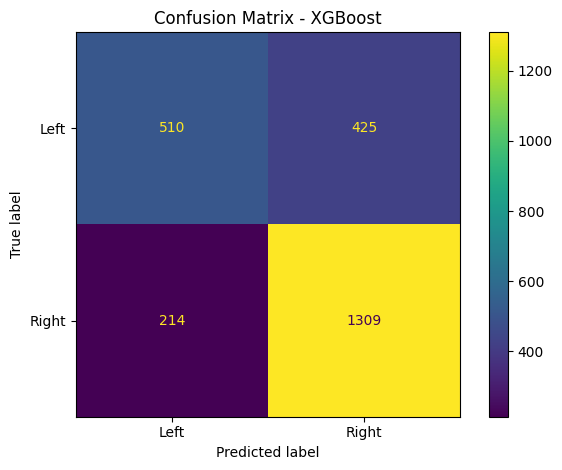

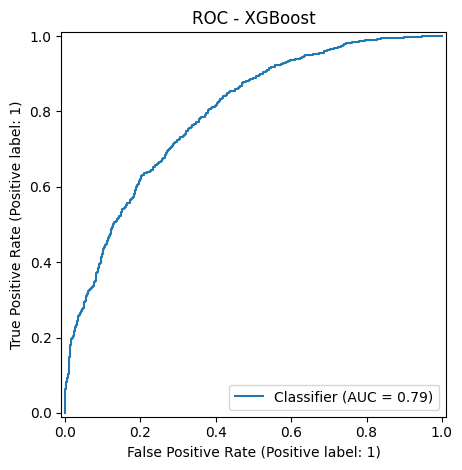

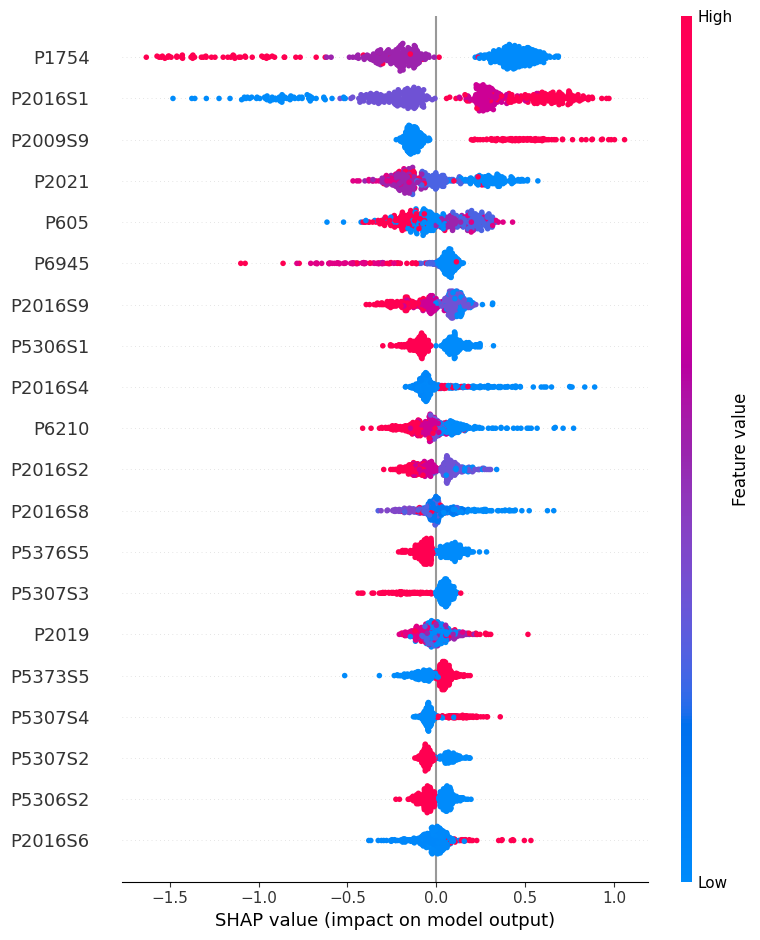


SHAP importance:
     feature  mean_abs_shap
49     P1754       0.433680
33   P2016S1       0.428272
72   P2009S9       0.212396
48     P2021       0.188915
2       P605       0.154549
..       ...            ...
22  P2003S12       0.000652
26  P2003S18       0.000309
18  P2001S10       0.000277
16  P2001S18       0.000229
10  P2001S17       0.000228

[73 rows x 2 columns]

Selected features: ['P1754', 'P2016S1', 'P2009S9', 'P2021', 'P605', 'P6945', 'P2016S9', 'P5306S1', 'P2016S4', 'P6210', 'P2016S2', 'P2016S8', 'P5376S5', 'P5307S3', 'P2019', 'P5373S5', 'P5307S4', 'P5307S2', 'P5306S2', 'P2016S6', 'P2016S5', 'P2017S6', 'P2016S3', 'P5314S4', 'P5314S2', 'P5376S6', 'P5307S5', 'P5317S1', 'P3039', 'P5317S5', 'P5314S7', 'P2057', 'P5376S1', 'P5317S4', 'P2017S1', 'P5376S4', 'P2016S7', 'P2017S2', 'P2017S5', 'P2017S3', 'P2003S14', 'P5307S1', 'P2017S4', 'P5373S4', 'P5317S9', 'P2001S4', 'P5376S3', 'P2001S1', 'P2017S7', 'P2003S4', 'P220', 'P2003S15', 'P5314S3', 'P5376S2', 'P5314S6', 'P5314S5', 'P20

In [25]:
# Modelos que NO soportan TreeExplainer
skip_shap_models = {"Logistic Regression", "Gradient Boosting"}

trained_models = {}
results = []

for model_name, model in models.items():
    trained_model, metrics_1, metrics_2, gap = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name, 
        params=parameters[model_name], 
        skip_shap=(model_name in skip_shap_models), 
        shap_threshold=0.01
    )

    trained_models[model_name] = trained_model
    results.append(metrics_1)

In [26]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
)

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
4,XGBoost,0.740033,0.754902,0.859488,0.803807,0.793416
3,Gradient Boosting,0.728641,0.733624,0.882469,0.801192,0.776690
2,Random Forest,0.697315,0.787454,0.700591,0.741487,0.771695
1,Decision Tree,0.657852,0.747820,0.675640,0.709900,0.720248
0,Logistic Regression,0.592352,0.705280,0.587656,0.641117,0.627272


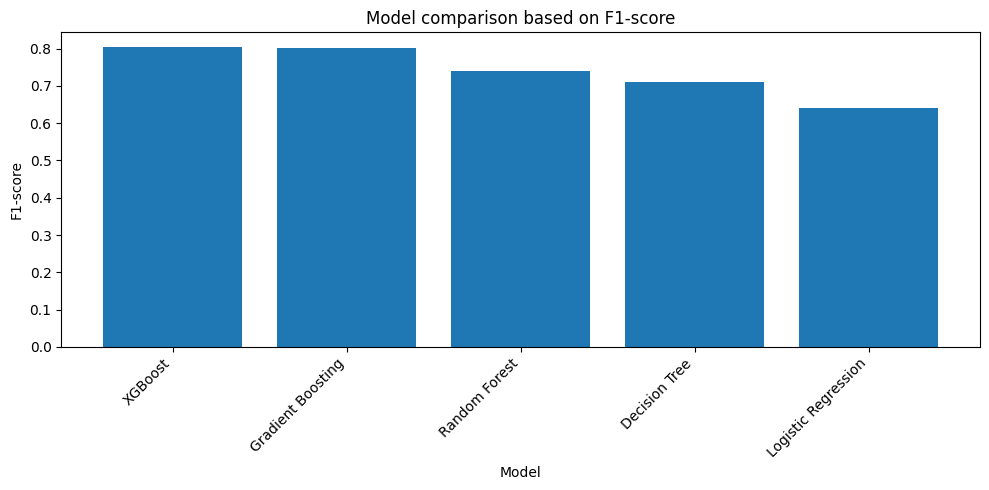

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["model"],
    results_df["f1_score"]
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title("Model comparison based on F1-score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()

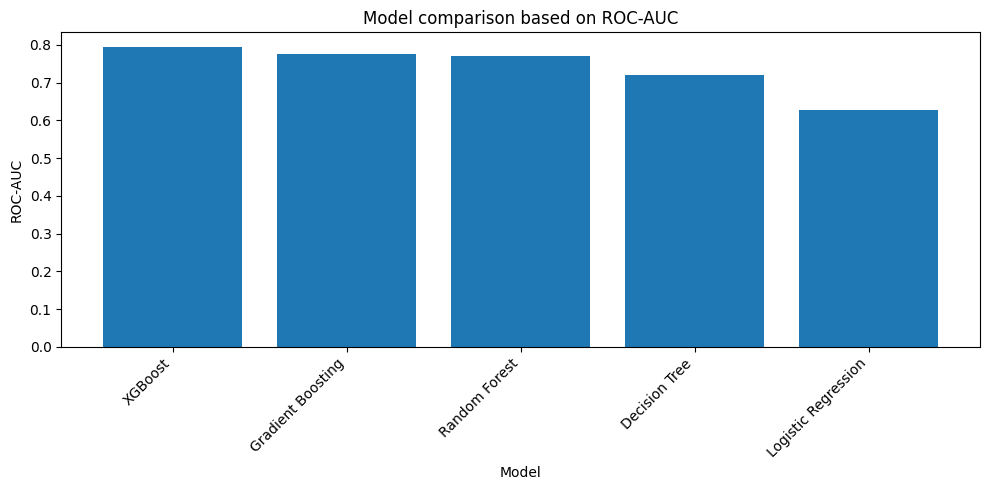

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["model"],
    results_df["roc_auc"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model comparison based on ROC-AUC")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/model_comparison_roc_auc.png", dpi=300, bbox_inches="tight")
plt.show()

------------------------------

## 6. Ajuste de hiperparámetros para el modelo XGBoost

Buscamos los mejores hiperparámetros para el mejor modelo que arrojó el análisis anterior

Mejores parámetros:
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Mejor CV score:
0.7867612797374898
XGBoost
              precision    recall  f1-score   support

        Left       0.70      0.56      0.62       935
       Right       0.76      0.86      0.81      1523

    accuracy                           0.74      2458
   macro avg       0.73      0.71      0.71      2458
weighted avg       0.74      0.74      0.74      2458

Gap ACC: 7.74% | F1: 5.91% | AUC: 10.28%
Posible overfitting


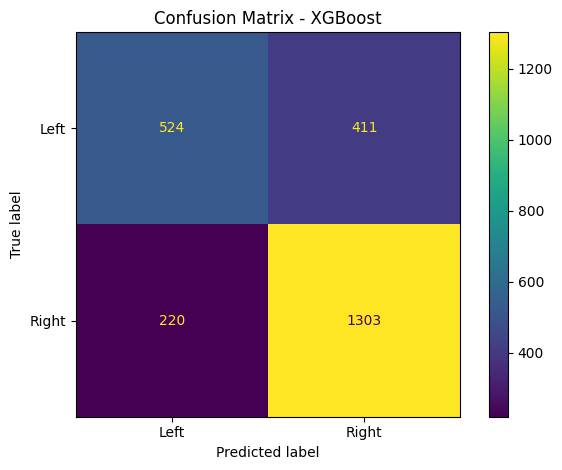

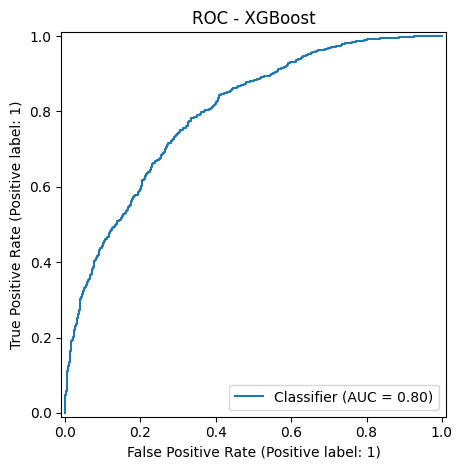

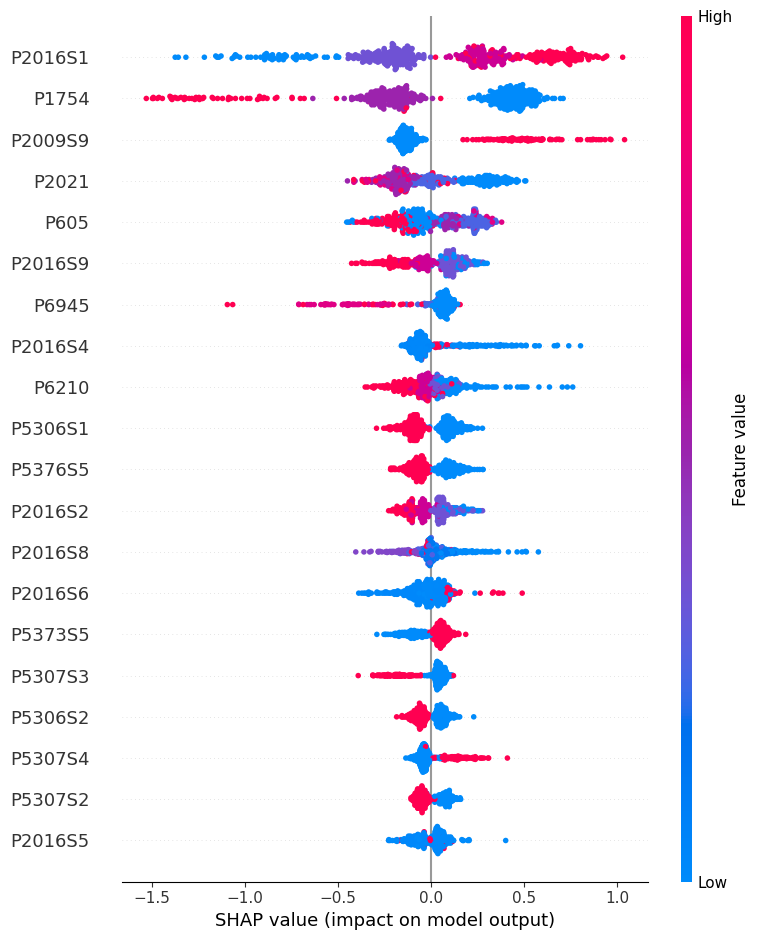


SHAP importance:
     feature  mean_abs_shap
1    P2016S1       0.428328
0      P1754       0.424117
2    P2009S9       0.217658
3      P2021       0.188977
4       P605       0.154121
6    P2016S9       0.127010
5      P6945       0.119075
8    P2016S4       0.106244
9      P6210       0.104641
7    P5306S1       0.104037
12   P5376S5       0.091270
10   P2016S2       0.087178
11   P2016S8       0.079713
19   P2016S6       0.074846
15   P5373S5       0.072417
13   P5307S3       0.071342
18   P5306S2       0.063735
16   P5307S4       0.063471
17   P5307S2       0.062221
20   P2016S5       0.062204
21   P2017S6       0.058570
26   P5307S5       0.057548
22   P2016S3       0.056655
14     P2019       0.056129
24   P5314S2       0.055534
23   P5314S4       0.052624
29   P5317S5       0.047187
25   P5376S6       0.046733
27   P5317S1       0.046512
30   P5314S7       0.040900
31     P2057       0.038639
38   P2017S5       0.036253
35   P5376S4       0.035124
34   P2017S1       0.034659
32

In [31]:
# Estos parámetros son seleccionados de las anteriores pruebas
# Solo se coloca a selección el min_samples_leaf

final_param = {
    "n_estimators":[200],
    "max_depth":[5],
    "learning_rate":[0.1],
    "subsample":[0.8],
    "colsample_bytree":[0.7]
}

final_model = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )


# Adicionalmente, se utilizan solo las variables relevantes según los valores SHAP para simplificar el modelo 

selected = ['P1754', 'P2016S1', 'P2009S9', 'P2021', 'P605', 'P6945', 'P2016S9', 'P5306S1', 'P2016S4', 'P6210', 
            'P2016S2', 'P2016S8', 'P5376S5', 'P5307S3', 'P2019', 'P5373S5', 'P5307S4', 'P5307S2', 'P5306S2', 
            'P2016S6', 'P2016S5', 'P2017S6', 'P2016S3', 'P5314S4', 'P5314S2', 'P5376S6', 'P5307S5', 'P5317S1', 
            'P3039', 'P5317S5', 'P5314S7', 'P2057', 'P5376S1', 'P5317S4', 'P2017S1', 'P5376S4', 'P2016S7', 'P2017S2',
              'P2017S5', 'P2017S3', 'P2003S14', 'P5307S1', 'P2017S4', 'P5373S4', 'P5317S9', 'P2001S4', 'P5376S3', 'P2001S1', 
              'P2017S7', 'P2003S4', 'P220', 'P2003S15', 'P5314S3', 'P5376S2', 'P5314S6', 'P5314S5', 'P2001S7', 'P5373S6']

X_train_filtered = X_train[selected]
X_test_filtered = X_test[selected]
y_train_filtered = y_train
y_test_filtered = y_test

trained_model, metrics_1, metrics_2, gap = evaluate_model(
        model=final_model,
        X_train=X_train_filtered,
        X_test=X_test_filtered,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name, 
        params=final_param, 
        skip_shap=(model_name in skip_shap_models), 
       
    )